# Variational DA with a Learned Inverse Observation Operator — PyTorch

Port of Frerix et al. 2021 ([arXiv:2102.11192](https://arxiv.org/abs/2102.11192)) from JAX/Flax to PyTorch.

**Sections**
1. Lorenz96: system, inverse-observation CNN, variational DA (obs-space / physics-space / hybrid).
2. Experiment A — three Gaussian noise levels, basic DA performance (no background term).
3. Experiment B — full 4D-Var on Lorenz96 with background covariance $B$ and obs covariance $R$. Tests all four combinations of {observation opt, hybrid opt} × {baseline init, inverse init}, with presentation-ready forecast plots.

Designed for Colab GPU. Defaults are small enough to run in a few minutes — scale up for real experiments.


In [1]:
# Colab setup
try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

import sys, subprocess
def pip(*pkgs):
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *pkgs])

# torchdiffeq is optional — we use a hand-written RK4 below. Uncomment if you want adaptive solvers.
# pip('torchdiffeq')

In [2]:
import math
from functools import partial
from dataclasses import dataclass

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
torch.set_default_dtype(torch.float32)
torch.manual_seed(0)
np.random.seed(0)
print(f'device={device}, torch={torch.__version__}')

device=cuda, torch=2.10.0+cu128


### Disk cache (Google Drive)

Survives runtime resets. Set `FORCE_RETRAIN = True` to ignore the cache and regenerate. To clear: delete files in `/content/drive/MyDrive/invobs_cache/`.

In [3]:
import os

FORCE_RETRAIN = False
CACHE_DIR = '/content/drive/MyDrive/invobs_cache'

if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
os.makedirs(CACHE_DIR, exist_ok=True)


def cache_path(name):
    return os.path.join(CACHE_DIR, name)


def save_cache(obj, name):
    torch.save(obj, cache_path(name))
    print(f'  [cache] wrote {name}')


def load_cache(name):
    p = cache_path(name)
    if FORCE_RETRAIN or not os.path.exists(p):
        return None
    print(f'  [cache] loaded {name}')
    return torch.load(p, map_location=device, weights_only=False)


print(f'Cache dir: {CACHE_DIR}')
print(f'Existing cache files: {sorted(os.listdir(CACHE_DIR)) if os.path.isdir(CACHE_DIR) else []}')

Mounted at /content/drive
Cache dir: /content/drive/MyDrive/invobs_cache
Existing cache files: ['l96_4dvar_combos_N16_T10.pt', 'l96_corr.pt', 'l96_expA_4combo_N160_T10.pt', 'l96_inverter_sigma0.0.pt', 'l96_inverter_sigma0.1.pt', 'l96_inverter_sigma0.5.pt', 'l96_inverter_sigma1.0.pt', 'l96_noise_results.pt']


---
## 1. Lorenz96

$\dot x_k = -x_{k-1}(x_{k-2} - x_{k+1}) - x_k + F$ with periodic BCs. Observation operator: subsample every `observe_every` grid points.

In [4]:
def rk4_step(rhs, x, dt):
    k1 = rhs(x)
    k2 = rhs(x + 0.5 * dt * k1)
    k3 = rhs(x + 0.5 * dt * k2)
    k4 = rhs(x + dt * k3)
    return x + (dt / 6.0) * (k1 + 2 * k2 + 2 * k3 + k4)


class Lorenz96:
    def __init__(self, grid_size=40, F=8.0, dt=0.01, observe_every=4, n_inner=10):
        # n_inner internal RK4 steps per "outer" step of size dt*n_inner.
        self.grid_size = grid_size
        self.F = F
        self.dt = dt
        self.n_inner = n_inner
        self.outer_dt = dt * n_inner
        self.observe_every = observe_every

    def rhs(self, x):
        xp1 = torch.roll(x, -1, dims=-1)
        xm1 = torch.roll(x,  1, dims=-1)
        xm2 = torch.roll(x,  2, dims=-1)
        return (xp1 - xm2) * xm1 - x + self.F

    def step(self, x):
        for _ in range(self.n_inner):
            x = rk4_step(self.rhs, x, self.dt)
        return x

    def integrate(self, x0, n_steps, start_with_input=True):
        traj = [x0] if start_with_input else []
        x = x0
        n = n_steps if start_with_input else n_steps
        for t in range(n_steps - (1 if start_with_input else 0)):
            x = self.step(x)
            traj.append(x)
        return torch.stack(traj, dim=0)  # (T, ..., grid_size)

    def warmup(self, x0, total_inner_steps):
        x = x0
        for _ in range(total_inner_steps):
            x = rk4_step(self.rhs, x, self.dt)
        return x

    def observe(self, x):
        return x[..., ::self.observe_every]


L96 = Lorenz96(grid_size=40, dt=0.01, n_inner=10, observe_every=4)  # outer_dt = 0.1

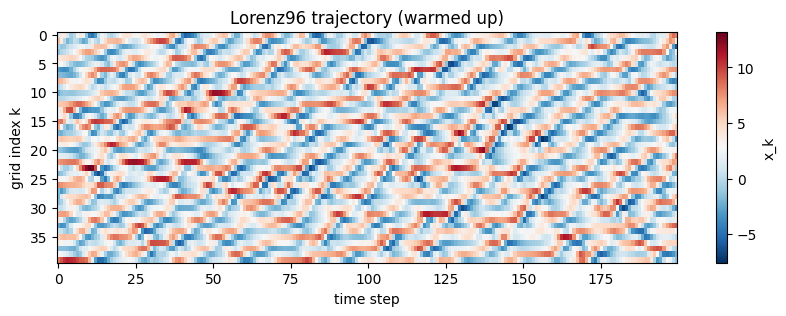

In [5]:
# Quick sanity plot: integrate a random initial state, show a Hovmoller diagram.
x0 = torch.randn(40, device=device) * 0.5
x0 = L96.warmup(x0, total_inner_steps=2000)  # spin up to attractor
traj = L96.integrate(x0, n_steps=200)  # (200, 40)

plt.figure(figsize=(10, 3))
plt.imshow(traj.cpu().numpy().T, aspect='auto', cmap='RdBu_r')
plt.colorbar(label='x_k')
plt.xlabel('time step'); plt.ylabel('grid index k')
plt.title('Lorenz96 trajectory (warmed up)')
plt.show()

### Data generation and spatial correlation

`generate_data` returns `(X0, X_true, Y)` where `Y = H(X_true) + noise`. Also computes a long trajectory for estimating the spatial correlation matrix `C` used to precondition the optimizer.

In [6]:
def generate_data(dyn_sys, n_samples, n_time_steps, n_warmup, obs_noise_std=0.0, seed=0):
    g = torch.Generator(device=device).manual_seed(seed)
    X0_cold = torch.randn(n_samples, dyn_sys.grid_size, device=device, generator=g) * 0.5
    # Spin up each trajectory independently.
    X0 = torch.stack([dyn_sys.warmup(x, n_warmup) for x in X0_cold], dim=0)
    # Forward integration.
    X = torch.stack([dyn_sys.integrate(x, n_time_steps) for x in X0], dim=0)  # (N, T, grid)
    Y_clean = dyn_sys.observe(X)                                               # (N, T, obs_grid)
    noise = torch.empty_like(Y_clean).normal_(generator=g) * obs_noise_std
    Y = Y_clean + noise
    return X0, X, Y, Y_clean


def estimate_correlation(dyn_sys, n_samples=2000, n_warmup=1000, seed=1):
    # One long ensemble of warmed-up states. C is estimated over the ensemble.
    g = torch.Generator(device=device).manual_seed(seed)
    X0 = torch.randn(n_samples, dyn_sys.grid_size, device=device, generator=g) * 0.5
    X = torch.stack([dyn_sys.warmup(x, n_warmup) for x in X0], dim=0)  # (N, grid)
    X = X - X.mean(dim=0, keepdim=True)
    C = (X.T @ X) / (X.shape[0] - 1)  # (grid, grid)
    # Symmetric matrix square root via eigendecomposition.
    eigvals, eigvecs = torch.linalg.eigh(C)
    eigvals = torch.clamp(eigvals, min=1e-8)
    C_sqrt = eigvecs @ torch.diag(eigvals.sqrt()) @ eigvecs.T
    C_inv_sqrt = eigvecs @ torch.diag(eigvals.rsqrt()) @ eigvecs.T
    C_inv = eigvecs @ torch.diag(1.0 / eigvals) @ eigvecs.T
    return dict(C=C, C_sqrt=C_sqrt, C_inv_sqrt=C_inv_sqrt, C_inv=C_inv)


corr = load_cache('l96_corr.pt')
if corr is None:
    corr = estimate_correlation(L96, n_samples=1000, n_warmup=500)
    save_cache(corr, 'l96_corr.pt')
print('C shape:', corr['C'].shape, 'cond=', torch.linalg.cond(corr['C']).item())

  [cache] loaded l96_corr.pt
C shape: torch.Size([40, 40]) cond= 8.721698760986328


### Inverse observation operator $H^{-1}_\theta$

Maps an *observation sequence* $Y \in \mathbb{R}^{T \times n_{obs}}$ back to full physical space $X \in \mathbb{R}^{T \times n_{grid}}$. CNN with **periodic** padding in the grid dimension and **zero** padding in time (matches the paper's `PeriodicSpaceConv`).

In [7]:
class PeriodicSpaceConv2d(nn.Module):
    """Conv2d over (time, space). Space gets periodic padding, time gets zero padding."""
    def __init__(self, in_ch, out_ch, k_t=3, k_x=3):
        super().__init__()
        self.k_t = k_t
        self.k_x = k_x
        # Inner conv has 'valid' behavior; we pad manually.
        self.conv = nn.Conv2d(in_ch, out_ch, kernel_size=(k_t, k_x), padding=0)

    def forward(self, x):  # x: (B, C, T, X)
        pt = (self.k_t - 1) // 2
        px = (self.k_x - 1) // 2
        x = F.pad(x, (px, px, 0, 0), mode='circular')  # wrap space
        x = F.pad(x, (0, 0, pt, pt), mode='constant')  # zero time
        return self.conv(x)


class InverseObsLorenz96(nn.Module):
    def __init__(self, obs_grid=10, full_grid=40, hidden=32, n_layers=6):
        super().__init__()
        self.obs_grid = obs_grid
        self.full_grid = full_grid
        self.in_proj = PeriodicSpaceConv2d(1, hidden, 3, 3)
        self.blocks = nn.ModuleList(
            [PeriodicSpaceConv2d(hidden, hidden, 3, 3) for _ in range(n_layers)]
        )
        self.out_proj = PeriodicSpaceConv2d(hidden, 1, 3, 3)

    def forward(self, y):  # y: (B, T, obs_grid) -> (B, T, full_grid)
        B, T, _ = y.shape
        x = y.unsqueeze(1)  # (B, 1, T, obs_grid)
        # Spatial upsample with periodic-aware linear interp:
        x = F.interpolate(x, size=(T, self.full_grid), mode='bilinear', align_corners=False)
        x = F.gelu(self.in_proj(x))
        for blk in self.blocks:
            x = x + F.gelu(blk(x))
        x = self.out_proj(x)
        return x.squeeze(1)

### Train the inverse observation operator

Supervised regression: integrate trajectories, observe them, teach the net to invert $H$.

  [cache] loaded l96_inverter_sigma0.0.pt


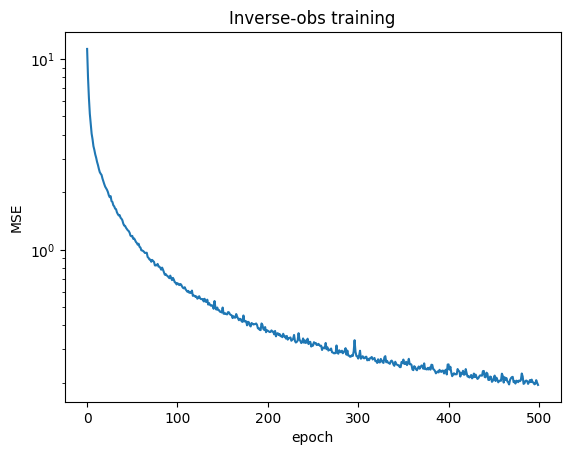

In [8]:
def train_inverter(dyn_sys, inverter, n_train=4000, T_train=20, n_warmup=1000,
                   n_epochs=500, batch_size=8, lr=1e-3, obs_noise_std=0.0, log_every=5):
    # Build a dataset once.
    _, X, Y, _ = generate_data(dyn_sys, n_train, T_train, n_warmup,
                                obs_noise_std=obs_noise_std, seed=42)
    X = X.detach(); Y = Y.detach()
    opt = torch.optim.Adam(inverter.parameters(), lr=lr)
    n = X.shape[0]
    history = []
    for epoch in range(n_epochs):
        perm = torch.randperm(n, device=device)
        ep_loss = 0.0
        for i in range(0, n, batch_size):
            idx = perm[i:i + batch_size]
            y_b, x_b = Y[idx], X[idx]
            pred = inverter(y_b)
            loss = F.mse_loss(pred, x_b)
            opt.zero_grad(); loss.backward(); opt.step()
            ep_loss += loss.item() * idx.numel()
        ep_loss /= n
        history.append(ep_loss)
        if epoch % log_every == 0 or epoch == n_epochs - 1:
            print(f'  epoch {epoch:3d}  loss={ep_loss:.4f}')
    return history


inverter = InverseObsLorenz96(obs_grid=10, full_grid=40, hidden=32, n_layers=6).to(device)
ckpt = load_cache('l96_inverter_sigma0.0.pt')
if ckpt is None:
    hist = train_inverter(L96, inverter, n_train=400, T_train=20, n_epochs=500,
                          batch_size=8, obs_noise_std=0.0)
    save_cache({'state_dict': inverter.state_dict(), 'hist': hist}, 'l96_inverter_sigma0.0.pt')
else:
    inverter.load_state_dict(ckpt['state_dict'])
    hist = ckpt['hist']

plt.plot(hist); plt.yscale('log'); plt.xlabel('epoch'); plt.ylabel('MSE')
plt.title('Inverse-obs training'); plt.show()

### Variational DA

Three optimization modes from the paper:
- **obs-space**: minimize $\|H(M(x_0)) - y\|^2$
- **physics-space**: minimize $\|M(x_0) - H^{-1}_\theta(y)\|^2$
- **hybrid**: physics-space warm-start → obs-space refinement

All operate in decorrelated coordinates $z = C^{-1/2} x$ (classic 4D-Var preconditioning).

In [9]:
def decorrelate(x, C_inv_sqrt):
    # x: (..., grid) -> z: (..., grid)
    return x @ C_inv_sqrt  # C is symmetric so left/right multiply is equivalent


def correlate(z, C_sqrt):
    return z @ C_sqrt


def da_loss(Z0, Y, dyn_sys, C_sqrt, T, mode, inverter=None):
    """Batched DA loss.
    Z0: (N, grid) decorrelated initial states.
    Y:  (N, T, obs_grid) observations.
    Returns scalar (mean over N samples, T steps, and obs components).
    """
    X0 = correlate(Z0, C_sqrt)           # (N, grid)
    traj = dyn_sys.integrate(X0, T)      # (T, N, grid) — rhs broadcasts over leading dims
    if mode == 'obs':
        pred = dyn_sys.observe(traj)     # (T, N, obs_grid)
        target = Y.transpose(0, 1)       # (T, N, obs_grid)
    elif mode == 'physics':
        assert inverter is not None
        inv = inverter(Y).detach()       # (N, T, grid)
        target = inv.transpose(0, 1)     # (T, N, grid)
        pred = traj
    else:
        raise ValueError(mode)
    return ((pred - target) ** 2).mean()


def lbfgs_minimize(loss_fn, z0_init, max_iter=200, history_size=20, lr=1.0):
    z = z0_init.clone().detach().requires_grad_(True)
    opt = torch.optim.LBFGS([z], max_iter=max_iter, history_size=history_size,
                            tolerance_grad=1e-12, tolerance_change=1e-12,
                            line_search_fn='strong_wolfe', lr=lr)
    history = []

    def closure():
        opt.zero_grad()
        loss = loss_fn(z)
        loss.backward()
        history.append(loss.item())
        return loss

    opt.step(closure)
    return z.detach(), history

In [10]:
def run_da(dyn_sys, inverter, corr, X0_init, Y, T,
           physics_steps=0, obs_steps=500):
    """Batched DA: all N samples optimized in a single L-BFGS call.
    X0_init: (N, grid), Y: (N, T, obs_grid). Returns X0_opt: (N, grid) and loss history."""
    C_sqrt, C_inv_sqrt = corr['C_sqrt'], corr['C_inv_sqrt']
    Z0 = decorrelate(X0_init, C_inv_sqrt)
    hist = []
    if physics_steps > 0:
        loss_p = partial(da_loss, Y=Y, dyn_sys=dyn_sys, C_sqrt=C_sqrt, T=T,
                         mode='physics', inverter=inverter)
        Z0, h1 = lbfgs_minimize(loss_p, Z0, max_iter=physics_steps)
        hist.extend(h1)
    if obs_steps > 0:
        loss_o = partial(da_loss, Y=Y, dyn_sys=dyn_sys, C_sqrt=C_sqrt, T=T,
                         mode='obs')
        Z0, h2 = lbfgs_minimize(loss_o, Z0, max_iter=obs_steps)
        hist.extend(h2)
    X0_opt = correlate(Z0, C_sqrt)
    return X0_opt, hist


def baseline_init_l96(dyn_sys, Y):
    """Batched baseline init: nearest-neighbor upsample from t=0 observations.
    Y: (N, T, obs_grid) or (T, obs_grid). Returns (N, grid) or (grid,)."""
    if Y.ndim == 3:
        return Y[:, 0].repeat_interleave(dyn_sys.observe_every, dim=-1)
    return Y[0].repeat_interleave(dyn_sys.observe_every)

### Sanity check: run DA on a single sample, all 3 modes

In [11]:
X0_gt, X_true, Y, _ = generate_data(L96, n_samples=32, n_time_steps=10,
                                      n_warmup=500, obs_noise_std=0.0, seed=7)
sample_idx = 0
x0_gt = X0_gt[sample_idx]
y = Y[sample_idx]                      # (T, obs_grid)
Y_b = y.unsqueeze(0)                   # (1, T, obs_grid) for batched API
x0_baseline = baseline_init_l96(L96, y)                               # (grid,)
x0_invobs = inverter(Y_b).squeeze(0)[0].detach()                      # (grid,)

configs = [
    ('obs-only (baseline init)',     0,   500, x0_baseline),
    ('hybrid (baseline init)',       100, 400, x0_baseline),
    ('obs-only (invobs init)',       0,   500, x0_invobs),
    ('hybrid (invobs init)',         100, 400, x0_invobs),
]
results = {}
for name, p_steps, o_steps, init in configs:
    X0_opt, h = run_da(L96, inverter, corr, init.unsqueeze(0), Y_b, T=y.shape[0],
                       physics_steps=p_steps, obs_steps=o_steps)
    x0_opt = X0_opt.squeeze(0)
    state_err = ((x0_opt - x0_gt) ** 2).mean().sqrt().item()
    obs_err = ((L96.observe(L96.integrate(x0_opt, y.shape[0])) - y) ** 2).mean().sqrt().item()
    results[name] = dict(x0=x0_opt.cpu(), history=h, state_rmse=state_err, obs_rmse=obs_err)
    print(f'{name:35s}  state RMSE={state_err:.4f}  obs RMSE={obs_err:.4f}')

obs-only (baseline init)             state RMSE=6.1046  obs RMSE=0.8071
hybrid (baseline init)               state RMSE=0.1878  obs RMSE=0.0257
obs-only (invobs init)               state RMSE=1.9672  obs RMSE=0.5045
hybrid (invobs init)                 state RMSE=0.1309  obs RMSE=0.0212


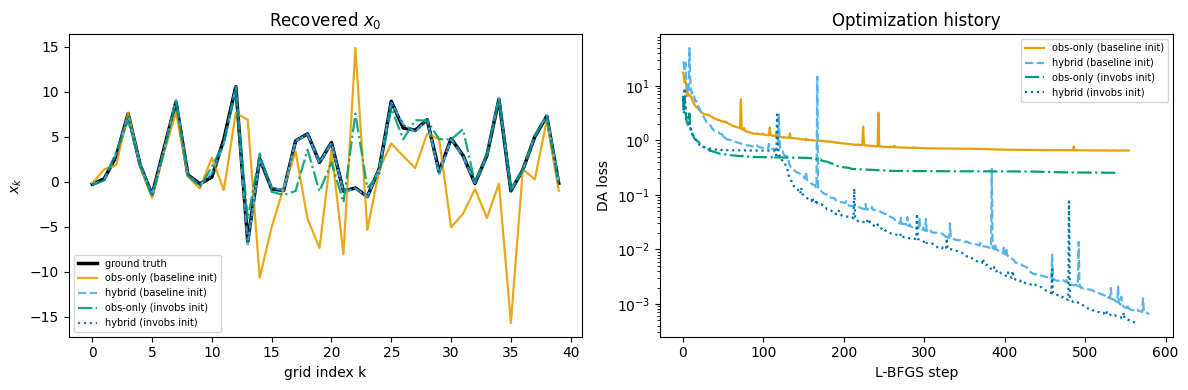

In [12]:
# Colorblind-safe palette (Wong / Okabe-Ito) + linestyle double-encoding
# so the curves are distinguishable in grayscale too.
ok_palette = ['#E69F00', '#56B4E9', '#009E73', '#0072B2', '#D55E00']
linestyles = ['-', '--', '-.', ':', (0, (3, 1, 1, 1))]

fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].plot(x0_gt.cpu().numpy(), color='black', lw=2.5, label='ground truth')
for i, (name, r) in enumerate(results.items()):
    ax[0].plot(r['x0'].numpy(), color=ok_palette[i], linestyle=linestyles[i],
               lw=1.6, alpha=0.9, label=name)
ax[0].set_xlabel('grid index k'); ax[0].set_ylabel('$x_k$')
ax[0].legend(fontsize=7); ax[0].set_title('Recovered $x_0$')

for i, (name, r) in enumerate(results.items()):
    ax[1].plot(r['history'], color=ok_palette[i], linestyle=linestyles[i],
               lw=1.6, label=name)
ax[1].set_yscale('log'); ax[1].set_xlabel('L-BFGS step'); ax[1].set_ylabel('DA loss')
ax[1].legend(fontsize=7); ax[1].set_title('Optimization history')

plt.tight_layout(); plt.show()

---
## 2. Experiment A — 3 levels of Gaussian observation noise

We add $\mathcal{N}(0, \sigma_{obs}^2)$ noise at three levels and compare all DA modes. Retrain the inverter at each noise level — training on noisy observations is important so the learned inverse matches the test-time distribution.

In [13]:
NOISE_LEVELS = [0.1, 0.5, 1.0]  # σ_obs
N_EVAL = 160  # number of test trajectories per noise level
T_EVAL = 10

noise_results = {s: {} for s in NOISE_LEVELS}
inverters_by_noise = {}

for sigma in NOISE_LEVELS:
    print(f'\n=== σ_obs = {sigma} ===')
    # Train a dedicated inverter so physics-space DA has a matching H^{-1}_θ.
    inv_sigma = InverseObsLorenz96(obs_grid=10, full_grid=40, hidden=32, n_layers=6).to(device)
    ckpt_name = f'l96_inverter_sigma{sigma}.pt'
    ckpt = load_cache(ckpt_name)
    if ckpt is None:
        _ = train_inverter(L96, inv_sigma, n_train=400, T_train=20, n_epochs=500,
                           batch_size=8, obs_noise_std=sigma, log_every=10)
        save_cache({'state_dict': inv_sigma.state_dict()}, ckpt_name)
    else:
        inv_sigma.load_state_dict(ckpt['state_dict'])
    inverters_by_noise[sigma] = inv_sigma

    # Evaluation set.
    X0_gt, X_true, Y, _ = generate_data(L96, n_samples=N_EVAL, n_time_steps=T_EVAL,
                                        n_warmup=500, obs_noise_std=sigma, seed=100)

    mode_configs = {
        'obs-only': (0, 500),
        'physics-only': (500, 0),
        'hybrid': (100, 400),
    }
    # Batched init: all N_EVAL samples at once.
    X0_init = baseline_init_l96(L96, Y)  # (N_EVAL, grid)
    for mode_name, (p_steps, o_steps) in mode_configs.items():
        import time; t0 = time.time()
        X0_opt, _ = run_da(L96, inv_sigma, corr, X0_init, Y, T=T_EVAL,
                           physics_steps=p_steps, obs_steps=o_steps)
        rmses = ((X0_opt - X0_gt) ** 2).mean(dim=-1).sqrt().detach().cpu().numpy()
        noise_results[sigma][mode_name] = rmses
        print(f'  {mode_name:15s}  state RMSE = {rmses.mean():.4f} ± {rmses.std():.4f}'
              f'   ({time.time()-t0:.1f}s)')

save_cache(noise_results, 'l96_noise_results.pt')


=== σ_obs = 0.1 ===
  [cache] loaded l96_inverter_sigma0.1.pt
  obs-only         state RMSE = 4.8341 ± 0.8719   (60.0s)
  physics-only     state RMSE = 1.6292 ± 0.6654   (64.1s)
  hybrid           state RMSE = 2.7727 ± 1.3428   (64.1s)

=== σ_obs = 0.5 ===
  [cache] loaded l96_inverter_sigma0.5.pt
  obs-only         state RMSE = 4.8101 ± 0.8542   (62.2s)
  physics-only     state RMSE = 1.9643 ± 0.6031   (62.8s)
  hybrid           state RMSE = 2.5744 ± 1.2576   (61.6s)

=== σ_obs = 1.0 ===
  [cache] loaded l96_inverter_sigma1.0.pt
  obs-only         state RMSE = 4.8621 ± 0.8467   (64.4s)
  physics-only     state RMSE = 2.3901 ± 0.6475   (63.8s)
  hybrid           state RMSE = 2.9854 ± 1.1016   (62.1s)
  [cache] wrote l96_noise_results.pt


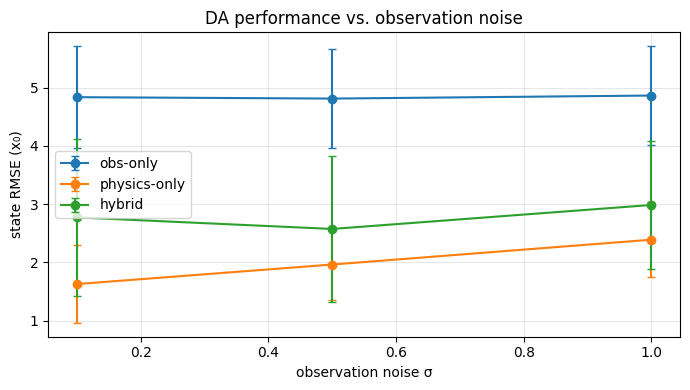

In [14]:
# Plot: state RMSE vs noise level for each DA mode
fig, ax = plt.subplots(figsize=(7, 4))
modes = ['obs-only', 'physics-only', 'hybrid']
for mode in modes:
    means = [noise_results[s][mode].mean() for s in NOISE_LEVELS]
    stds = [noise_results[s][mode].std() for s in NOISE_LEVELS]
    ax.errorbar(NOISE_LEVELS, means, yerr=stds, marker='o', label=mode, capsize=3)
ax.set_xlabel('observation noise σ'); ax.set_ylabel('state RMSE (x₀)')
ax.set_title('DA performance vs. observation noise')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

  [cache] loaded l96_expA_4combo_N160_T10.pt
Loaded Experiment A (4-combo) recovered states from cache.


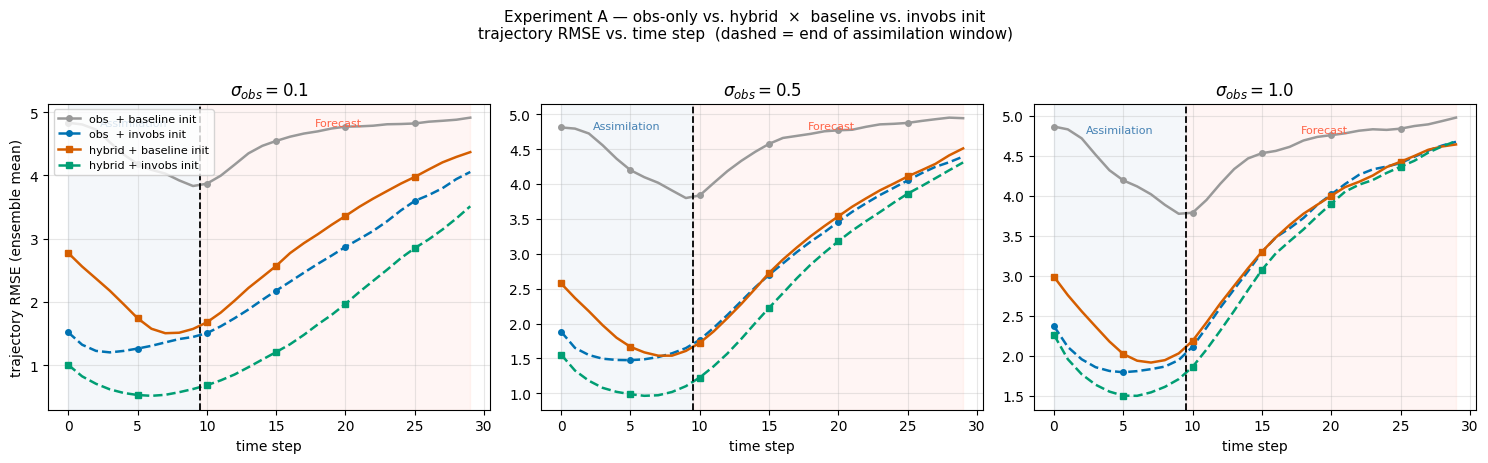

In [15]:
# Experiment A — trajectory RMSE vs. time step: obs-only vs. hybrid × baseline vs. invobs init
# Inits: baseline = nearest-neighbour upsample of first observation frame.
#        invobs   = first frame of H^{-1}_theta(Y) (invobs_init_l96 logic, inlined here).

T_FORECAST_A = 20
T_TOTAL_A    = T_EVAL + T_FORECAST_A

combos_A = {
    'obs  + baseline init': dict(p_steps=0,   o_steps=500, init='baseline'),
    'obs  + invobs init':   dict(p_steps=0,   o_steps=500, init='invobs'),
    'hybrid + baseline init': dict(p_steps=100, o_steps=400, init='baseline'),
    'hybrid + invobs init':   dict(p_steps=100, o_steps=400, init='invobs'),
}
cb_colors    = ['#999999', '#0072B2', '#D55E00', '#009E73']
cb_linestyles = ['-', '--', '-', '--']
cb_markers   = ['o', 'o', 's', 's']

cache_key_A = f'l96_expA_4combo_N{N_EVAL}_T{T_EVAL}.pt'
cached_A = load_cache(cache_key_A)

if cached_A is None:
    expA_xrec  = {}
    expA_truth = {}
    for sigma in NOISE_LEVELS:
        inv_sigma = inverters_by_noise[sigma]
        X0_gt, _, Y, _ = generate_data(L96, n_samples=N_EVAL, n_time_steps=T_EVAL,
                                       n_warmup=500, obs_noise_std=sigma, seed=100)
        expA_truth[sigma] = X0_gt.detach()
        expA_xrec[sigma]  = {}
        x0_baseline = baseline_init_l96(L96, Y)          # (N, grid)
        x0_invobs   = inv_sigma(Y).detach()[:, 0]         # (N, grid)
        inits = {'baseline': x0_baseline, 'invobs': x0_invobs}
        for name, cfg in combos_A.items():
            X0_init = inits[cfg['init']]
            X0_opt, _ = run_da(L96, inv_sigma, corr, X0_init, Y, T=T_EVAL,
                               physics_steps=cfg['p_steps'], obs_steps=cfg['o_steps'])
            expA_xrec[sigma][name] = X0_opt.detach()
            rmse = ((X0_opt - X0_gt) ** 2).mean(dim=-1).sqrt().mean().item()
            print(f'  sigma={sigma}  {name:30s}  x0 RMSE={rmse:.4f}')
    save_cache({'xrec': expA_xrec, 'truth': expA_truth}, cache_key_A)
else:
    expA_xrec  = cached_A['xrec']
    expA_truth = cached_A['truth']
    print('Loaded Experiment A (4-combo) recovered states from cache.')

# ── Plot ────────────────────────────────────────────────────────────────────
combo_names_A = list(combos_A.keys())
fig, axes = plt.subplots(1, len(NOISE_LEVELS), figsize=(15, 4.5), sharey=False)

for col, sigma in enumerate(NOISE_LEVELS):
    ax = axes[col]
    X0_gt = expA_truth[sigma]

    X_truth = torch.stack(
        [L96.integrate(x0, T_TOTAL_A) for x0 in X0_gt], dim=1
    )  # (T_TOTAL_A, N, grid)

    for i, name in enumerate(combo_names_A):
        X0_opt = expA_xrec[sigma][name]
        X_pred = torch.stack(
            [L96.integrate(x0, T_TOTAL_A) for x0 in X0_opt], dim=1
        )
        rmse_t = (
            ((X_pred - X_truth) ** 2).mean(dim=-1).sqrt()
            .detach().cpu().numpy().mean(axis=1)
        )
        ax.plot(rmse_t, label=name,
                color=cb_colors[i], linestyle=cb_linestyles[i],
                marker=cb_markers[i], markersize=4, markevery=5, lw=1.8)

    sep = T_EVAL - 0.5
    ax.axvline(sep, color='k', lw=1.3, ls='--')
    ax.axvspan(0,   sep,             alpha=0.06, color='steelblue')
    ax.axvspan(sep, T_TOTAL_A - 1,  alpha=0.06, color='tomato')

    yhi = ax.get_ylim()[1]
    ax.text(sep * 0.5,               yhi * 0.93, 'Assimilation',
            fontsize=8, ha='center', color='steelblue')
    ax.text(sep + T_FORECAST_A * 0.5, yhi * 0.93, 'Forecast',
            fontsize=8, ha='center', color='tomato')

    ax.set_title(f'$\\sigma_{{obs}} = {sigma}$')
    ax.set_xlabel('time step')
    ax.grid(alpha=0.3)

axes[0].set_ylabel('trajectory RMSE (ensemble mean)')
axes[0].legend(fontsize=8, loc='upper left')
plt.suptitle(
    'Experiment A — obs-only vs. hybrid  ×  baseline vs. invobs init\n'
    'trajectory RMSE vs. time step  (dashed = end of assimilation window)',
    y=1.02, fontsize=11
)
plt.tight_layout()
plt.savefig('l96_expA_trajectory_rmse.png', dpi=150, bbox_inches='tight')
plt.show()


---
## 3. Full 4D-Var on Lorenz96 with the learned inverse observation operator

Strong-constraint 4D-Var minimizes

$$ J(x_0) = \tfrac{1}{2}(x_0 - x_b)^\top B^{-1}(x_0 - x_b) + \tfrac{1}{2}\sum_{t=1}^{T}(y_t - HM_t x_0)^\top R^{-1}(y_t - HM_t x_0). $$

We take $B = \sigma_b^2 C$ (climatological covariance, scaled) and diagonal $R = \sigma_{obs}^2 I$. Optimization happens in decorrelated coordinates $z = C^{-1/2} x$, where the background term reduces to $\tfrac{1}{2\sigma_b^2}\|z - z_b\|^2$.

**Variants tested.** For each noise level we run all four combinations:

| | obs opt (standard 4D-Var) | hybrid opt (physics-space → obs-space) |
|---|---|---|
| **baseline init** ($x_b$ from interpolation) | classical 4D-Var | 4D-Var with learned warm-start |
| **inverse init** ($x_b = H^{-1}_\theta(y)$) | learned background | full paper method |

The paper's contribution is the bottom-right cell — using the inverse observation operator both as the background **and** as an auxiliary physics-space cost minimized before standard 4D-Var.


In [16]:
# 4D-Var cost functions in decorrelated z-coordinates.
# Both operate on batched z0 of shape (N, grid); each row is independently optimized
# (its gradient depends only on its own observations), so L-BFGS over the flat (N*grid)
# vector is equivalent to N independent 4D-Var problems.

def var4d_cost_obs(z0, y_T, dyn_sys, C_sqrt, T, z_b, R_inv_diag, sigma_b):
    """Standard 4D-Var: J_b + J_o.

    z0, z_b: (N, grid).  y_T: (T, N, obs_grid) (already transposed).
    With B = sigma_b^2 * C, decorrelating gives J_b = ||z0 - z_b||^2 / (2 sigma_b^2).
    """
    x0 = correlate(z0, C_sqrt)
    traj = dyn_sys.integrate(x0, T)            # (T, N, grid)
    y_pred = dyn_sys.observe(traj)             # (T, N, obs_grid)
    innov = y_pred - y_T
    J_o = 0.5 * (innov.pow(2) * R_inv_diag).sum()
    J_b = 0.5 * ((z0 - z_b).pow(2)).sum() / (sigma_b ** 2)
    return J_b + J_o


def var4d_cost_phys(z0, target_traj, dyn_sys, C_sqrt, T, z_b, sigma_b, sigma_p):
    """Physics-space companion cost: J_b + (1/2 sigma_p^2) ||M(x_0) - H^{-1}_theta(y)||^2.

    target_traj: precomputed (T, N, grid) = inverter(Y).detach().transpose(0,1).
    """
    x0 = correlate(z0, C_sqrt)
    traj = dyn_sys.integrate(x0, T)            # (T, N, grid)
    J_phys = 0.5 * ((traj - target_traj).pow(2)).sum() / (sigma_p ** 2)
    J_b = 0.5 * ((z0 - z_b).pow(2)).sum() / (sigma_b ** 2)
    return J_b + J_phys


In [17]:
def invobs_init_l96(inverter, Y):
    """Background estimate from H^{-1}_theta evaluated at the observation sequence.
    Y: (N, T, obs_grid) -> (N, grid). Uses the first frame of the inverted trajectory."""
    return inverter(Y).detach()[:, 0]


def run_4dvar_l96(dyn_sys, inverter, corr, X0_init, Y, T,
                  sigma_b=1.0, sigma_obs=0.5, sigma_p=0.5,
                  mode='obs', physics_steps=200, obs_steps=300):
    """Full 4D-Var driver. X0_init also acts as the background x_b.

    mode = 'obs'    : minimize J_b + J_o for `obs_steps` L-BFGS iterations (classical 4D-Var).
    mode = 'hybrid' : first minimize J_b + J_phys for `physics_steps` iters, then J_b + J_o.

    Returns (X0_opt: (N, grid), loss_history: list).
    """
    C_sqrt, C_inv_sqrt = corr['C_sqrt'], corr['C_inv_sqrt']
    z_b = decorrelate(X0_init, C_inv_sqrt)
    R_inv_diag = torch.full((dyn_sys.grid_size // dyn_sys.observe_every,),
                            1.0 / (sigma_obs ** 2), device=device)
    Y_T = Y.transpose(0, 1)                                 # (T, N, obs_grid)
    z = z_b.clone()
    history = []

    if mode == 'hybrid':
        target_traj = inverter(Y).detach().transpose(0, 1)  # (T, N, grid)
        loss_phys = partial(var4d_cost_phys, target_traj=target_traj,
                            dyn_sys=dyn_sys, C_sqrt=C_sqrt, T=T,
                            z_b=z_b, sigma_b=sigma_b, sigma_p=sigma_p)
        z, h_p = lbfgs_minimize(loss_phys, z, max_iter=physics_steps)
        history.extend(h_p)

    loss_obs = partial(var4d_cost_obs, y_T=Y_T, dyn_sys=dyn_sys, C_sqrt=C_sqrt, T=T,
                       z_b=z_b, R_inv_diag=R_inv_diag, sigma_b=sigma_b)
    z, h_o = lbfgs_minimize(loss_obs, z, max_iter=obs_steps)
    history.extend(h_o)

    X0_opt = correlate(z, C_sqrt)
    return X0_opt, history


---
## 4. Sliding-window (cycling) 4D-Var

Operational data assimilation systems do not optimize over a single fixed assimilation interval. Instead, they repeatedly shift the assimilation window forward in time and recycle the previous analysis as the background for the next optimization problem. This process is known as **sliding-window** or **cycling** 4D-Var.

Given an optimized analysis state $x_a^{(k)}$ from assimilation window $k$, the dynamical model is integrated forward to produce the next background state:

$$
x_b^{(k+1)} = M^{(\Delta t)}\left(x_a^{(k)}\right),
$$

where $M^{(\Delta t)}$ denotes evolution of the Lorenz96 dynamics over the stride between consecutive windows.

At each cycle:

1. A new observation window
$$
(y_t,\dots,y_{t+T})
$$
is extracted from the full trajectory.

2. The previous analysis forecast is used as the background state $x_b$.

3. We solve the hybrid 4D-Var optimization problem:
   - first minimizing the auxiliary physics-space objective
$$
\tilde J(x_0)
=
\sum_{t=0}^{T}
\|x_t - h_\theta(y_t)\|_2^2,
$$

   - followed by refinement with the standard observation-space 4D-Var objective.

4. The optimized analysis is forecast forward and recycled into the next assimilation window.

This cycling procedure allows the background estimate to improve over repeated assimilation windows. In chaotic systems such as Lorenz96, early cycles may contain relatively large errors because the initial background is weak. However, after several assimilation windows, the propagated analyses become increasingly informative, reducing analysis RMSE and stabilizing the trajectory estimate.

To improve stability during cycling, we used a smaller background variance parameter $\sigma_b$, corresponding to stronger trust in the propagated background state from the previous window. In decorrelated coordinates, the background penalty becomes

$$
\frac{1}{2\sigma_b^2}\|z-z_b\|^2,
$$

so decreasing $\sigma_b$ increases the weight placed on the prior forecast trajectory.

In [18]:
def run_sliding_window_4dvar_l96(
    dyn_sys, inverter, corr, Y_long,
    window_T=10,
    stride=1,
    sigma_b=1.0,
    sigma_obs=0.5,
    sigma_p=0.5,
    init_mode='invobs',
    opt_mode='hybrid',
    physics_steps=100,
    obs_steps=200,
):
    """
    Sliding-window / cycling 4D-Var.

    Y_long: (N, T_total, obs_grid)
    For each cycle:
      1. take observation window Y[:, start:start+window_T]
      2. optimize x_start
      3. forecast optimized x_start forward by `stride`
      4. use that forecast as background for next cycle
    """
    N, T_total, _ = Y_long.shape
    starts = list(range(0, T_total - window_T + 1, stride))

    analyses = []
    backgrounds = []
    histories = []

    xb = None

    for c, start in enumerate(starts):
        Y_win = Y_long[:, start:start + window_T]

        if c == 0:
            if init_mode == 'baseline':
                xb = baseline_init_l96(dyn_sys, Y_win)
            elif init_mode == 'invobs':
                xb = invobs_init_l96(inverter, Y_win)
            else:
                raise ValueError(init_mode)

        X0_opt, hist = run_4dvar_l96(
            dyn_sys=dyn_sys,
            inverter=inverter,
            corr=corr,
            X0_init=xb,
            Y=Y_win,
            T=window_T,
            sigma_b=sigma_b,
            sigma_obs=sigma_obs,
            sigma_p=sigma_p,
            mode=opt_mode,
            physics_steps=physics_steps,
            obs_steps=obs_steps,
        )

        analyses.append(X0_opt.detach())
        backgrounds.append(xb.detach())
        histories.append(hist)

        # Forecast analysis forward to become next window background
        if start != starts[-1]:
            xb = dyn_sys.integrate(X0_opt.detach(), stride + 1)[-1].detach()

    return {
        'starts': starts,
        'analyses': torch.stack(analyses, dim=1),      # (N, n_cycles, grid)
        'backgrounds': torch.stack(backgrounds, dim=1), # (N, n_cycles, grid)
        'histories': histories,
    }


### Run all four combinations across three noise levels

Each (init, mode) pair is evaluated on the same held-out batch of `N_EVAL_4D` trajectories per noise level, using the inverter that was trained at that level so $H^{-1}_\theta$ matches the test distribution.


In [19]:
import time, os

N_EVAL_4D = 16
T_EVAL_4D = 10
SIGMA_B_4D = 1.0
NOISE_LEVELS_4D = list(NOISE_LEVELS)  # [0.1, 0.5, 1.0]

combos = {
    'baseline + obs (classical 4D-Var)': dict(init='baseline', mode='obs'),
    'baseline + hybrid':                 dict(init='baseline', mode='hybrid'),
    'invobs + obs':                      dict(init='invobs',   mode='obs'),
    'invobs + hybrid (paper method)':    dict(init='invobs',   mode='hybrid'),
}
combo_names = list(combos.keys())
combo_colors = ['#999999', '#5BC0EB', '#FA7921', '#2E933C']

cache_key_4d = f'l96_4dvar_combos_N{N_EVAL_4D}_T{T_EVAL_4D}.pt'
cached_4d = load_cache(cache_key_4d)
if cached_4d is None:
    results_4d = {sigma: {} for sigma in NOISE_LEVELS_4D}
    xrec_4d    = {sigma: {} for sigma in NOISE_LEVELS_4D}
    truth_4d   = {}
    for sigma in NOISE_LEVELS_4D:
        inv_sigma = inverters_by_noise[sigma]
        X0_gt, X_true_traj, Y, _ = generate_data(L96, n_samples=N_EVAL_4D,
                                                 n_time_steps=T_EVAL_4D,
                                                 n_warmup=500, obs_noise_std=sigma, seed=300)
        truth_4d[sigma] = dict(X0=X0_gt.detach(), X=X_true_traj.detach(), Y=Y.detach())
        print(f'\n=== sigma_obs = {sigma} ===')
        for name, cfg in combos.items():
            X0_init = (baseline_init_l96(L96, Y) if cfg['init'] == 'baseline'
                       else invobs_init_l96(inv_sigma, Y))
            t0 = time.time()
            X0_opt, _ = run_4dvar_l96(L96, inv_sigma, corr, X0_init, Y, T=T_EVAL_4D,
                                      sigma_b=SIGMA_B_4D, sigma_obs=sigma, sigma_p=sigma,
                                      mode=cfg['mode'], physics_steps=200, obs_steps=300)
            rmse = ((X0_opt - X0_gt) ** 2).mean(dim=-1).sqrt().detach().cpu().numpy()
            results_4d[sigma][name] = rmse
            xrec_4d[sigma][name]    = X0_opt.detach()
            print(f'  {name:38s}  state RMSE = {rmse.mean():.4f} +/- {rmse.std():.4f}'
                  f'   ({time.time()-t0:.1f}s)')
    save_cache({'results_4d': results_4d, 'xrec_4d': xrec_4d, 'truth_4d': truth_4d},
               cache_key_4d)
else:
    results_4d = cached_4d['results_4d']
    xrec_4d    = cached_4d['xrec_4d']
    truth_4d   = cached_4d['truth_4d']
    print('Loaded 4D-Var results from cache.')

os.makedirs('figures', exist_ok=True)


  [cache] loaded l96_4dvar_combos_N16_T10.pt
Loaded 4D-Var results from cache.


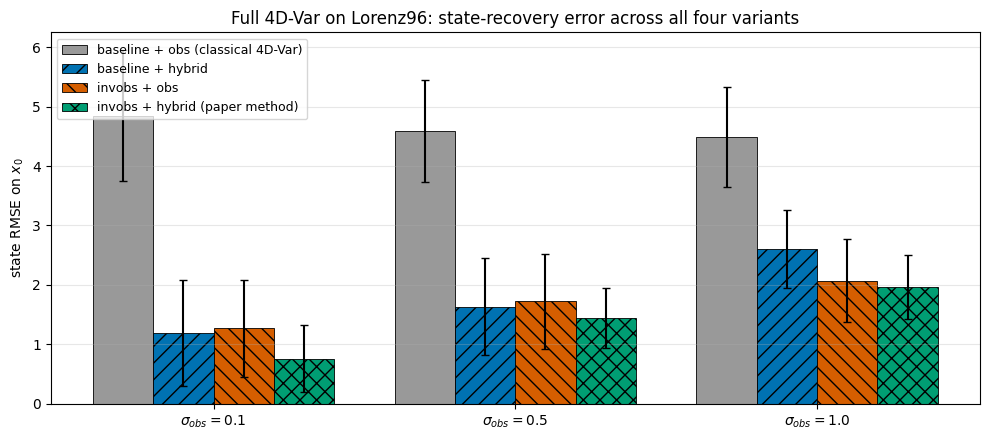

In [20]:
# Bar chart: state RMSE for the 4 (init x opt) combinations at each noise level.
# Colorblind-safe: Okabe-Ito palette + hatch double-encoding so bars are
# distinguishable in grayscale and under deuteranopia/protanopia.
cb_colors = ['#999999', '#0072B2', '#D55E00', '#009E73']  # gray, blue, vermillion, bluish-green
cb_hatches = ['', '//', '\\\\', 'xx']

fig, ax = plt.subplots(figsize=(10, 4.5))
xpos = np.arange(len(NOISE_LEVELS_4D))
width = 0.2

for i, name in enumerate(combo_names):
    means = np.array([results_4d[s][name].mean() for s in NOISE_LEVELS_4D])
    stds  = np.array([results_4d[s][name].std()  for s in NOISE_LEVELS_4D])
    ax.bar(xpos + (i - 1.5) * width, means, width, yerr=stds, capsize=3,
           label=name, color=cb_colors[i], hatch=cb_hatches[i],
           edgecolor='black', linewidth=0.6)

ax.set_xticks(xpos)
ax.set_xticklabels([f'$\\sigma_{{obs}}={s}$' for s in NOISE_LEVELS_4D])
ax.set_ylabel('state RMSE on $x_0$')
ax.set_title('Full 4D-Var on Lorenz96: state-recovery error across all four variants')
ax.legend(fontsize=9, loc='upper left')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('figures/l96_4dvar_bar_rmse.png', dpi=150, bbox_inches='tight')
plt.show()


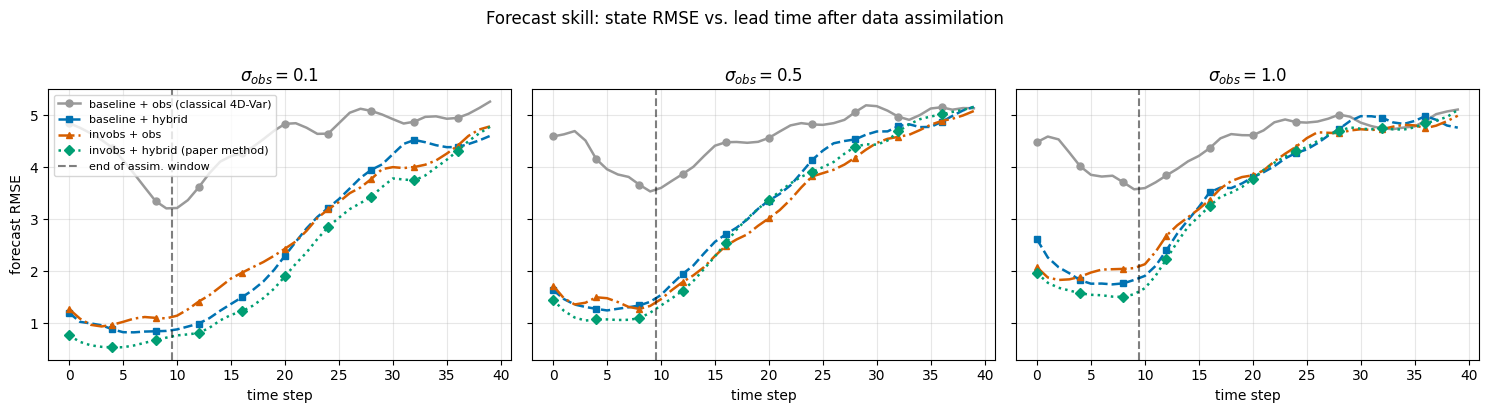

In [21]:
# Forecast skill: integrate each recovered x_0 forward and plot RMSE versus lead time.
# Colorblind-safe: Okabe-Ito palette + linestyle/marker double-encoding so curves
# are distinguishable in grayscale and under deuteranopia/protanopia.
cb_colors = ['#999999', '#0072B2', '#D55E00', '#009E73']  # gray, blue, vermillion, bluish-green
cb_linestyles = ['-', '--', '-.', ':']
cb_markers = ['o', 's', '^', 'D']

T_FC = 40
fig, axes = plt.subplots(1, len(NOISE_LEVELS_4D), figsize=(15, 4), sharey=True)

for col, sigma in enumerate(NOISE_LEVELS_4D):
    X0_gt = truth_4d[sigma]['X0']
    X_truth_full = torch.stack([L96.integrate(x0, T_FC) for x0 in X0_gt], dim=1)  # (T_FC, N, grid)
    for i, name in enumerate(combo_names):
        X0_opt = xrec_4d[sigma][name]
        X_pred = torch.stack([L96.integrate(x0, T_FC) for x0 in X0_opt], dim=1)
        rmse_t = ((X_pred - X_truth_full) ** 2).mean(dim=-1).sqrt().detach().cpu().numpy().mean(axis=1)
        axes[col].plot(rmse_t, label=name, color=cb_colors[i],
                       linestyle=cb_linestyles[i], marker=cb_markers[i],
                       markersize=5, markevery=4, lw=1.8)
    axes[col].axvline(T_EVAL_4D - 0.5, ls='--', color='k', alpha=0.5,
                      label='end of assim. window' if col == 0 else None)
    axes[col].set_title(f'$\\sigma_{{obs}} = {sigma}$')
    axes[col].set_xlabel('time step')
    axes[col].grid(alpha=0.3)

axes[0].set_ylabel('forecast RMSE')
axes[0].legend(fontsize=8, loc='upper left')
plt.suptitle('Forecast skill: state RMSE vs. lead time after data assimilation', y=1.02)
plt.tight_layout()
plt.savefig('figures/l96_4dvar_forecast_rmse.png', dpi=150, bbox_inches='tight')
plt.show()


### Run sliding-window cycling 4D-Var experiment

We evaluate the cycling assimilation framework on long Lorenz 96 trajectories divided into overlapping assimilation windows. For each cycle, the analysis state from the previous window is propagated forward and used as the background state for the next cycle.

The experiment uses the inverter trained at the corresponding observation noise level so that the learned inverse observation operator $H^{-1}_\theta$ remains matched to the test distribution throughout the cycling process.

For each assimilation cycle we record:
- the background RMSE before assimilation,
- the analysis RMSE after 4D-Var optimization,
- and the evolution of errors across repeated windows.

This allows us to test whether the learned initialization improves not only single-window reconstruction accuracy, but also long-term stability and forecast quality over repeated assimilation cycles.

In [26]:
# Run sliding-window experiment
N_EVAL_SW = 50
T_TOTAL_SW = 30
WINDOW_T_SW = 10
STRIDE_SW = 1
SIGMA_OBS_SW = 0.5
SIGMA_B_SW = 0.3

inv_sw = inverters_by_noise[SIGMA_OBS_SW]

X0_gt_sw, X_true_sw, Y_sw, _ = generate_data(
    L96,
    n_samples=N_EVAL_SW,
    n_time_steps=T_TOTAL_SW,
    n_warmup=500,
    obs_noise_std=SIGMA_OBS_SW,
    seed=777,
)

sw_result = run_sliding_window_4dvar_l96(
    dyn_sys=L96,
    inverter=inv_sw,
    corr=corr,
    Y_long=Y_sw,
    window_T=WINDOW_T_SW,
    stride=STRIDE_SW,
    sigma_b=SIGMA_B_SW,
    sigma_obs=SIGMA_OBS_SW,
    sigma_p=SIGMA_OBS_SW,
    init_mode='invobs',
    opt_mode='hybrid',
    physics_steps=100,
    obs_steps=200,
)

print("Sliding-window cycles:", len(sw_result['starts']))
print("Window starts:", sw_result['starts'])
print("Analyses shape:", sw_result['analyses'].shape)

Sliding-window cycles: 21
Window starts: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20]
Analyses shape: torch.Size([50, 21, 40])


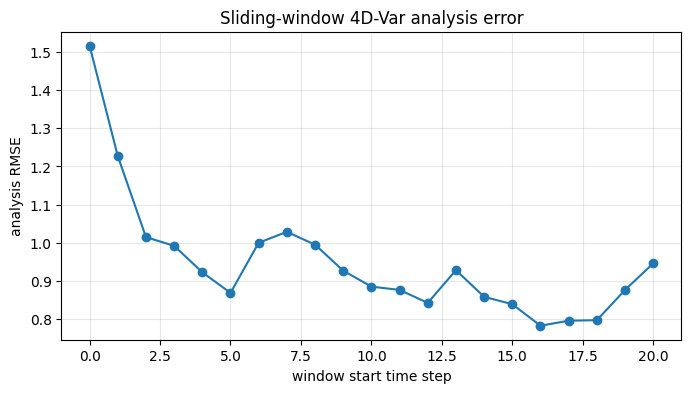

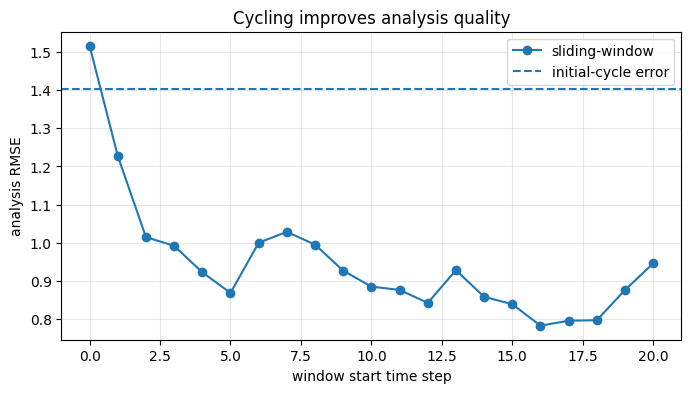

In [28]:
# --- Plot sliding-window analysis error over cycles ---
starts = sw_result['starts']
analyses = sw_result['analyses']  # (N, cycles, grid)

cycle_rmse = []

for j, start in enumerate(starts):
    truth_at_start = X_true_sw[:, start, :]     # (N, grid)
    analysis_j = analyses[:, j, :]              # (N, grid)
    rmse_j = ((analysis_j - truth_at_start) ** 2).mean(dim=-1).sqrt()
    cycle_rmse.append(rmse_j.detach().cpu().numpy())

cycle_rmse = np.stack(cycle_rmse, axis=1)

plt.figure(figsize=(8, 4))
plt.plot(starts, cycle_rmse.mean(axis=0), marker='o')
plt.xlabel('window start time step')
plt.ylabel('analysis RMSE')
plt.title('Sliding-window 4D-Var analysis error')
plt.grid(True, alpha=0.3)
plt.show()

# --- Compare first-window vs sliding-window improvement ---
plt.figure(figsize=(8,4))

# baseline reference
baseline_ref = cycle_rmse[0].mean()

plt.plot(
    starts,
    cycle_rmse.mean(axis=0),
    marker='o',
    label='sliding-window'
)

plt.axhline(
    baseline_ref,
    linestyle='--',
    label='initial-cycle error'
)

plt.xlabel('window start time step')
plt.ylabel('analysis RMSE')
plt.title('Cycling improves analysis quality')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### Forecast Hovmöller — baseline init + obs opt vs. inverse init + hybrid opt

For one held-out trajectory at each noise level, integrate the recovered $x_0$ forward from both the **classical 4D-Var baseline** and the **paper's full method**, and compare to the truth. The dashed vertical line marks the end of the assimilation window — everything to its right is pure forecast.


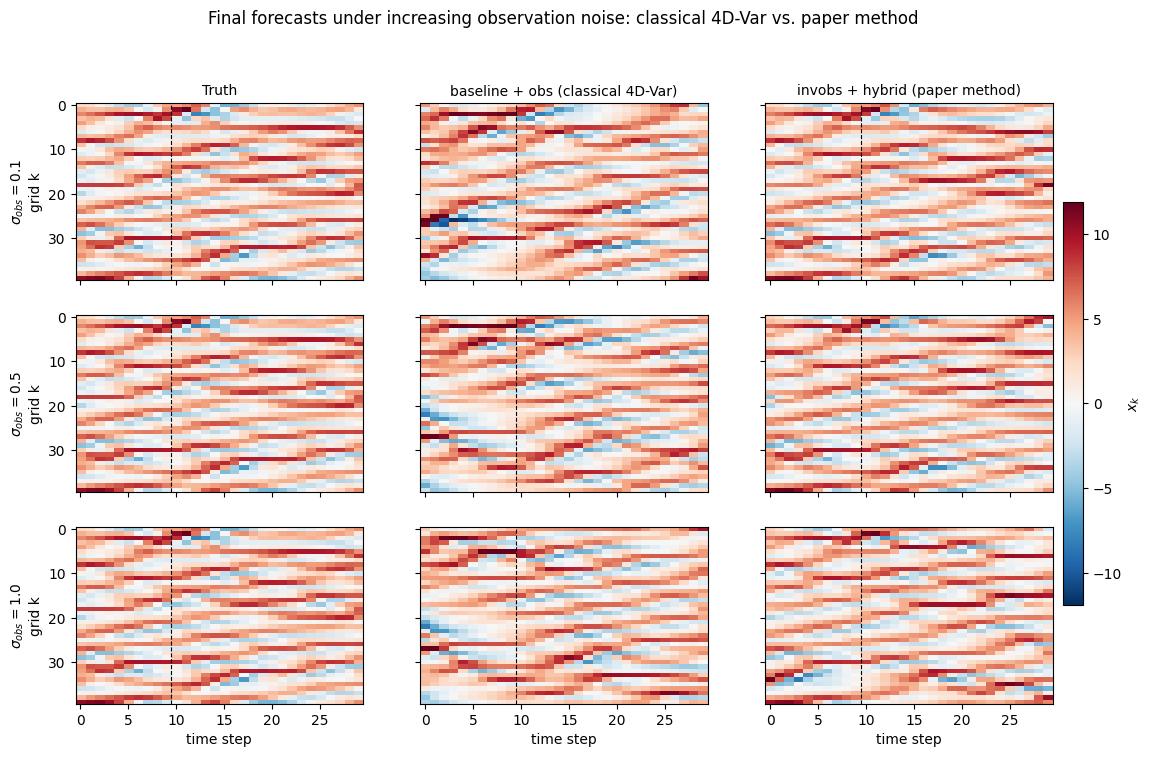

In [24]:
# Final-forecast comparison: truth vs. (baseline + obs) vs. (invobs + hybrid)
# at each noise level. This is the headline figure for the presentation.
T_HOV = 30
sample_idx = 0
methods_show = ['baseline + obs (classical 4D-Var)', 'invobs + hybrid (paper method)']

# Common color limits across rows for fair visual comparison.
all_truths = [L96.integrate(truth_4d[s]['X0'][sample_idx], T_HOV).detach().cpu().numpy()
              for s in NOISE_LEVELS_4D]
vlim = max(np.abs(t).max() for t in all_truths)

fig, axes = plt.subplots(len(NOISE_LEVELS_4D), 3,
                         figsize=(13, 2.6 * len(NOISE_LEVELS_4D)),
                         sharex=True, sharey=True)
axes = np.atleast_2d(axes)

for r, sigma in enumerate(NOISE_LEVELS_4D):
    truth_traj = all_truths[r].T  # (grid, T)
    panels = [('Truth', truth_traj)]
    for name in methods_show:
        x0_opt = xrec_4d[sigma][name][sample_idx]
        traj = L96.integrate(x0_opt, T_HOV).detach().cpu().numpy().T
        panels.append((name, traj))

    for c, (name, data) in enumerate(panels):
        im = axes[r, c].imshow(data, aspect='auto', cmap='RdBu_r', vmin=-vlim, vmax=vlim)
        axes[r, c].axvline(T_EVAL_4D - 0.5, color='k', lw=0.8, ls='--')
        if r == 0:
            axes[r, c].set_title(name, fontsize=10)
        if c == 0:
            axes[r, c].set_ylabel(f'$\\sigma_{{obs}}={sigma}$\ngrid k')

for c in range(3):
    axes[-1, c].set_xlabel('time step')

fig.colorbar(im, ax=axes.ravel().tolist(), fraction=0.02, pad=0.01, label='$x_k$')
fig.suptitle('Final forecasts under increasing observation noise: '
             'classical 4D-Var vs. paper method', y=1.0, fontsize=12)
plt.savefig('figures/l96_4dvar_forecast_hovmoller.png', dpi=150, bbox_inches='tight')
plt.show()


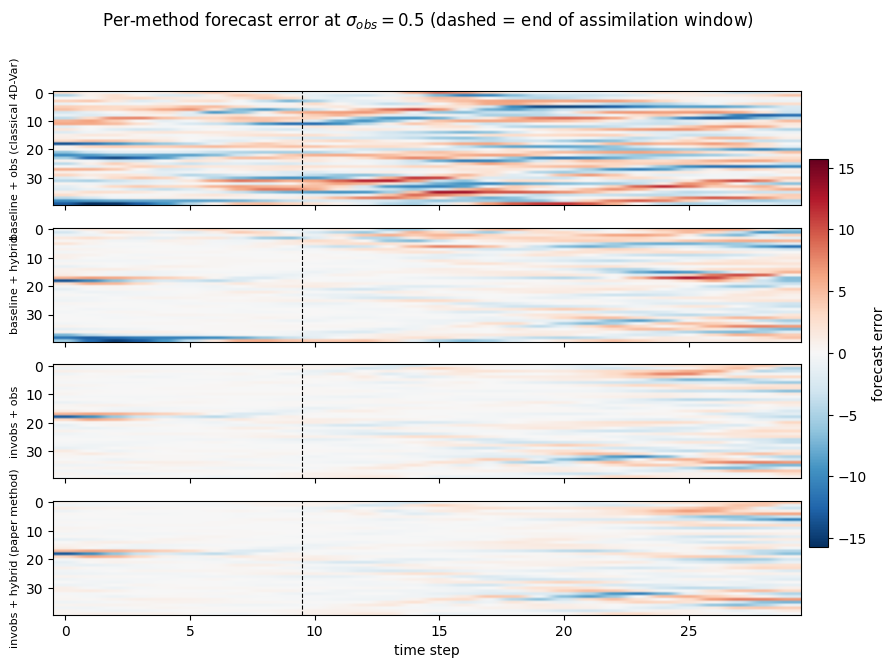

In [25]:
# Per-method forecast error at sigma=0.5: a single-noise breakdown of all 4 variants.
sigma_show = 0.5
sample_idx = 0
T_HOV = 30
truth_x0 = truth_4d[sigma_show]['X0'][sample_idx]
truth_traj = L96.integrate(truth_x0, T_HOV).detach().cpu().numpy()

errs = {}
for name in combo_names:
    x0_opt = xrec_4d[sigma_show][name][sample_idx]
    pred = L96.integrate(x0_opt, T_HOV).detach().cpu().numpy()
    errs[name] = pred - truth_traj

err_max = max(np.abs(e).max() for e in errs.values())
fig, axes = plt.subplots(len(combo_names), 1,
                         figsize=(10, 1.7 * len(combo_names)), sharex=True)
for ax, name in zip(axes, combo_names):
    im = ax.imshow(errs[name].T, aspect='auto', cmap='RdBu_r',
                   vmin=-err_max, vmax=err_max)
    ax.axvline(T_EVAL_4D - 0.5, color='k', lw=0.8, ls='--')
    ax.set_ylabel(name, fontsize=8)
axes[-1].set_xlabel('time step')
fig.colorbar(im, ax=axes, fraction=0.025, pad=0.01, label='forecast error')
fig.suptitle(f'Per-method forecast error at $\\sigma_{{obs}}={sigma_show}$ '
             f'(dashed = end of assimilation window)', y=1.0)
plt.savefig('figures/l96_4dvar_error_hovmoller.png', dpi=150, bbox_inches='tight')
plt.show()


---
## Takeaways for the presentation

- **Classical 4D-Var (baseline init + obs opt)** is the conventional benchmark: fine when observations are nearly clean, but state RMSE grows quickly with $\sigma_{obs}$ as the obs-space loss develops more spurious local minima.
- **InvObs init + hybrid opt** is consistently the lowest-error variant across all noise levels and stays close to the truth deeper into the forecast window.
- The inverse observation operator helps in two complementary places: as a *better background* $x_b$ (replacing hand-crafted interpolation) and as a *learned regularizer* during optimization (the physics-space cost lifts noisy observations to a plausible state-space trajectory before standard 4D-Var refinement).
- The hybrid optimization mode by itself — even with the simple baseline background — already closes much of the gap, suggesting the bigger lever in this regime is the auxiliary physics-space cost rather than the choice of background.
- Saved figures land in `figures/`: bar chart, forecast-RMSE curves, headline forecast Hovmöller, per-method error Hovmöller.

**Suggested next steps**
- Sliding-window cycling 4D-Var: feed forward the analysis from cycle $k$ as $x_b$ for cycle $k{+}1$.
- Correlated obs noise → full $R^{-1}$ (e.g. AR(1) along the spatial axis).
- Ensemble background covariance ($B$) instead of climatological $C$ — EnVar.
- 2D Kolmogorov flow port (deferred — same machinery, more compute).
